In [86]:
import sys
import os
from pathlib import Path
# Go up until you find the project root
while not (Path.cwd() / ".gitignore").exists() and Path.cwd() != Path("/"):
    os.chdir("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

results_df_detailed = pd.read_csv('output/integration_geoplant/geoplant_partition_detailed_summary.csv')
auc_cols   = ["AUC_PO_only", "AUC_PA_only", "AUC_PO_plus_PA",
               "AUC_PO_plus_PA_ens", "AUC_PO_plus_PA_smooth"]
auc_cols_sp = [f'{c}_sp' for c in auc_cols]
results_df_detailed.groupby(['species', 'split_type'])[auc_cols_sp].mean().groupby('split_type').mean()


,AUC_PO_only_sp,AUC_PA_only_sp,AUC_PO_plus_PA_sp,AUC_PO_plus_PA_ens_sp,AUC_PO_plus_PA_smooth_sp
split_type,,,,,
closest,0.614648,0.636577,NaN,NaN,0.680936
farthest,0.613791,0.536255,NaN,NaN,0.648463
middle,0.614879,0.611142,NaN,NaN,0.653798


[0.57762, 0.61553, nan, nan, 0.6386499999999999]
[0.5780199999999999, 0.60084, nan, nan, 0.6130000000000001]
[0.57743, 0.57239, nan, nan, 0.5997600000000001]


/Users/pubillap/Documents/EcoControl/data-integration-sdm/myenv/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/pubillap/Documents/EcoControl/data-integration-sdm/myenv/lib/python3.9/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/pubillap/Documents/EcoControl/data-integration-sdm/myenv/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/pubillap/Documents/EcoControl/data-integration-sdm/myenv/lib/python3.9/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/pubillap/Documents/EcoControl/data-integration-sdm/myenv/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean

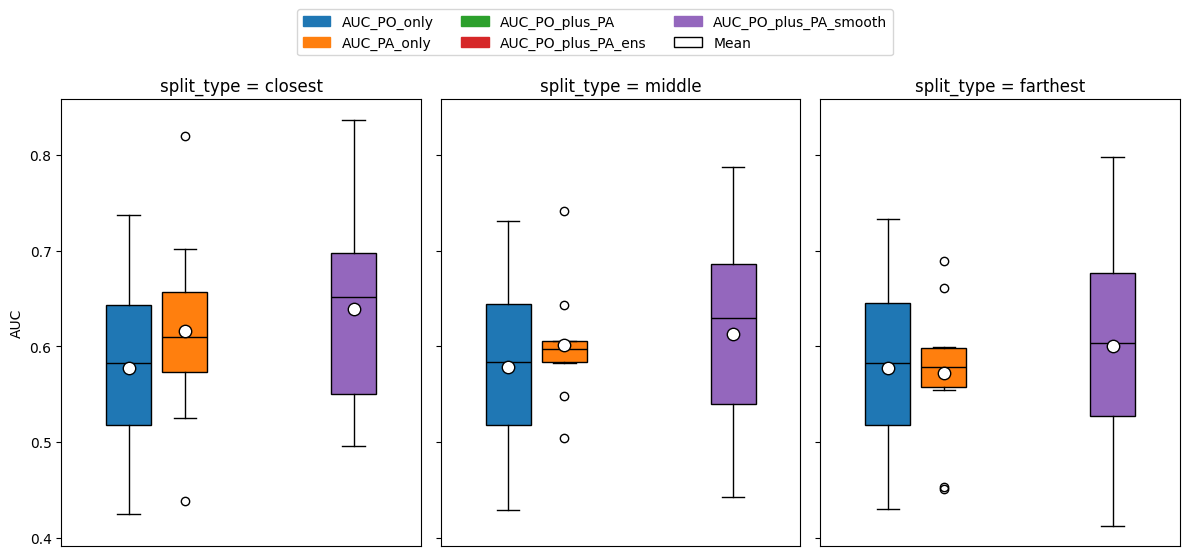

[0.6146479027777777, 0.6365767268518517, nan, nan, 0.6809357685185184]
[0.6148794675925926, 0.6111424490740739, nan, nan, 0.6537982083333334]
[0.6137907824074075, 0.5362552916666666, nan, nan, 0.648463300925926]


/Users/pubillap/Documents/EcoControl/data-integration-sdm/myenv/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/pubillap/Documents/EcoControl/data-integration-sdm/myenv/lib/python3.9/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/pubillap/Documents/EcoControl/data-integration-sdm/myenv/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/pubillap/Documents/EcoControl/data-integration-sdm/myenv/lib/python3.9/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/pubillap/Documents/EcoControl/data-integration-sdm/myenv/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean

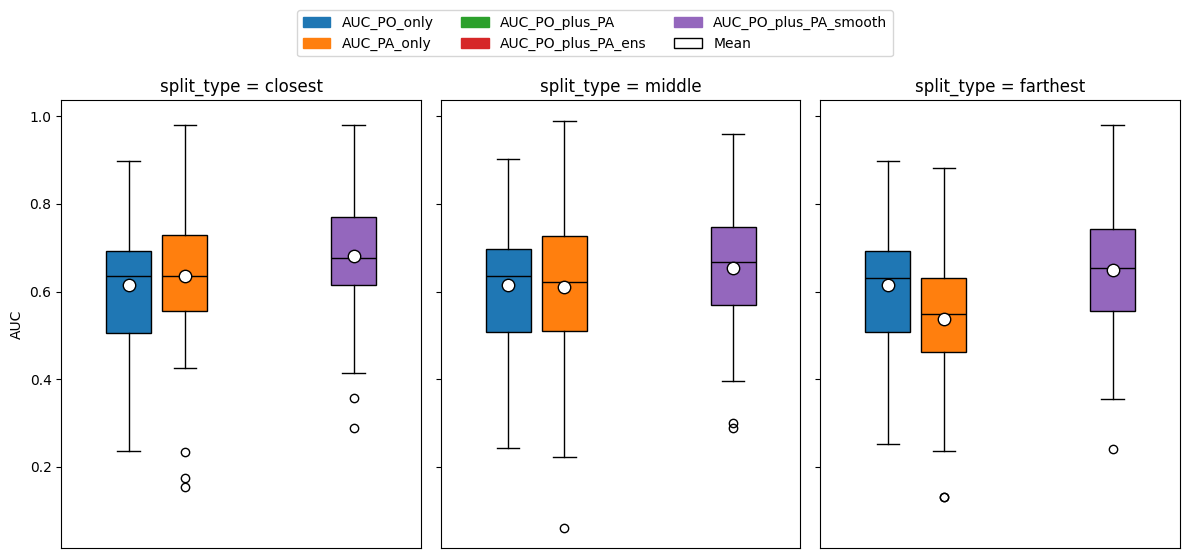

In [120]:
import matplotlib.patches as mpatches
import numpy as np

auc_cols    = ["AUC_PO_only", "AUC_PA_only", "AUC_PO_plus_PA",
               "AUC_PO_plus_PA_ens", "AUC_PO_plus_PA_smooth"]
auc_cols_sp = [f'{c}_sp' for c in auc_cols]
colors      = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]
split_types = ['closest', 'middle', 'farthest']

fig, axes = plt.subplots(
    1, len(split_types),
    figsize=(4 * len(split_types), 5),
    sharey=True
)

if len(split_types) == 1:
    axes = [axes]

n_box = len(auc_cols)
positions = np.linspace(-1, 1, n_box)
width     = 2/n_box  

for ax, split in zip(axes, split_types):
    df_sub = results_df_detailed[results_df_detailed["split_type"] == split]

    # take average over species for each method
    data = []
    for c in auc_cols_sp:
        species_means = df_sub.groupby('species')[c].mean().dropna().values
        data.append(species_means)

    # Boxplot
    bp = ax.boxplot(
        data,
        positions=positions,
        widths=width,
        patch_artist=True,
        medianprops=dict(color="black")
    )

    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)

    # === Mean Markers Only ===
    means = [np.mean(d) for d in data]
    print(means)
    ax.scatter(
        positions,
        means,
        s=80,
        marker='o',
        edgecolor='black',
        facecolor='white',
        zorder=3,
        label="Mean"
    )

    ax.set_title(f"split_type = {split}")
    ax.set_xlim(-1.6, 1.6)
    ax.set_xticks([])

axes[0].set_ylabel("AUC")

# Legend
handles = [mpatches.Patch(color=c, label=l) for c, l in zip(colors, auc_cols)]
handles.append(
    mpatches.Patch(facecolor="white", edgecolor="black", label="Mean (○)")
)

fig.legend(handles, [*auc_cols, "Mean"], loc="upper center",
           ncol=3, bbox_to_anchor=(0.5, 1.12))

plt.tight_layout()
plt.show()


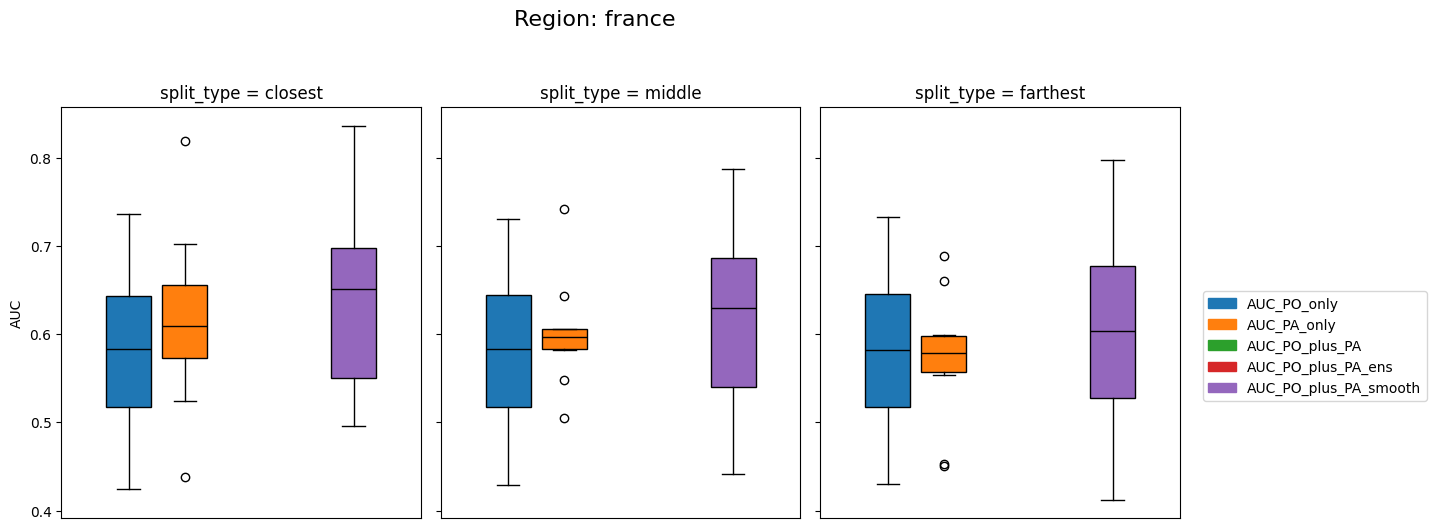

In [ ]:
# unique_regions = results_df['region'].unique()
# for region in unique_regions:
#     df_region = results_df[results_df['region'] == region]

#     auc_cols    = ["AUC_PO_only", "AUC_PA_only", "AUC_PO_plus_PA",
#                 "AUC_PO_plus_PA_ens", "AUC_PO_plus_PA_smooth"]
#     colors      = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]
#     split_types = ['closest', 'middle', 'farthest']

#     fig, axes = plt.subplots(
#         1, len(split_types),
#         figsize=(4 * len(split_types), 5),
#         sharey=True
#     )
#     if len(split_types) == 1:
#         axes = [axes]

#     # positions = np.array([-1, 0, 1])   # centers
#     n_box = len(auc_cols)
#     positions = np.linspace(-1, 1, n_box)  # spread out
#     # width     = 1.0                    # full width -> boxes just touch
#     width     =  2/n_box            # narrower boxes

#     for ax, split in zip(axes, split_types):
#         df_sub = df_region[df_region["split_type"] == split]
#         data   = [df_sub[c].dropna().values for c in auc_cols]

#         bp = ax.boxplot(
#             data,
#             positions=positions,
#             widths=width,
#             patch_artist=True,
#             medianprops=dict(color="black")

#         )

#         for patch, color in zip(bp["boxes"], colors):
#             patch.set_facecolor(color)

#         ax.set_title(f"split_type = {split}")
#         ax.set_xlim(-1.6, 1.6)
#         ax.set_xticks([])

#     axes[0].set_ylabel("AUC")

#     # add title
#     fig.suptitle(f"Region: {region}", y=1.05, fontsize=16)

#     handles = [mpatches.Patch(color=c, label=l) for c, l in zip(colors, auc_cols)]
#     fig.legend(handles, auc_cols, loc="upper center", ncol=1, bbox_to_anchor=(1.1, .5))

#     plt.tight_layout()
#     plt.show()


<Axes: xlabel='train_test_dist'>

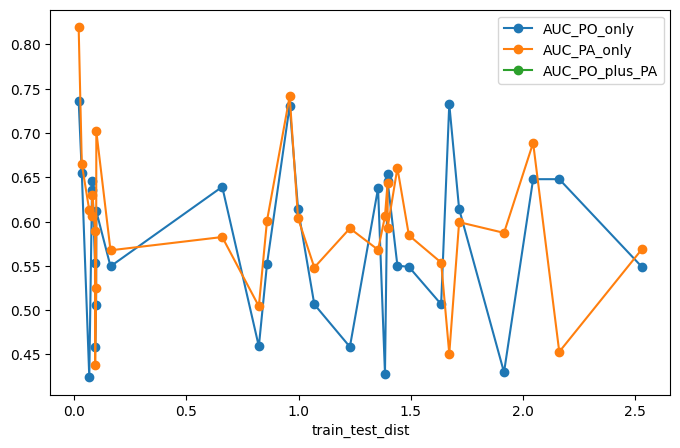

In [93]:
results_df.sort_values(by = 'train_test_dist').plot(
    x="train_test_dist",
    y=["AUC_PO_only", "AUC_PA_only", "AUC_PO_plus_PA"],
    kind="line",
    marker="o",
    figsize=(8,5)
)


<Axes: xlabel='train_test_dist'>

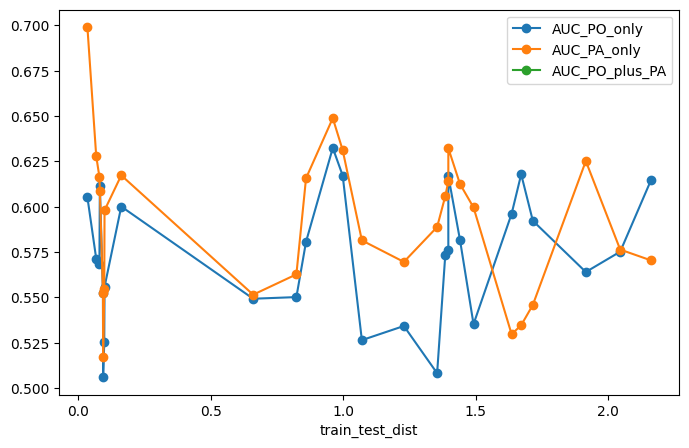

In [94]:
df = results_df.sort_values('train_test_dist').copy()

# Apply rolling mean smoothing (window=3 is typical; adjust as needed)
df[['AUC_PO_only', 'AUC_PA_only', 'AUC_PO_plus_PA']] = (
    df[['AUC_PO_only', 'AUC_PA_only', 'AUC_PO_plus_PA']]
      .rolling(window=3, center=True)
      .mean()
)

df.plot(
    x="train_test_dist",
    y=["AUC_PO_only", "AUC_PA_only", "AUC_PO_plus_PA"],
    kind="line",
    marker="o",
    figsize=(8,5)
)


In [95]:
# from statsmodels.nonparametric.smoothers_lowess import lowess

# df = results_df.sort_values('train_test_dist').copy()

# for col in ["AUC_PO_only", "AUC_PA_only", "AUC_PO_plus_PA"]:
#     smoothed = lowess(df[col], df['train_test_dist'], frac=0.3)
#     df[col] = smoothed[:,1]

# df.plot(
#     x="train_test_dist",
#     y=["AUC_PO_only", "AUC_PA_only", "AUC_PO_plus_PA"],
#     kind="line",
#     figsize=(8,5)
# )


In [ ]:
## probably shouldnt use this code as this is not valid when there are missing species

# import matplotlib.patches as mpatches
# import numpy as np

# # mean by region
# results_df = pd.read_csv('output/integration_geoplant/geoplant_partition_summary.csv')
# auc_cols    = ["AUC_PO_only", "AUC_PA_only", "AUC_PO_plus_PA",
#                "AUC_PO_plus_PA_ens", "AUC_PO_plus_PA_smooth"]
# results_df.groupby(['region', 'split_type'])[auc_cols].mean()

# auc_cols    = ["AUC_PO_only", "AUC_PA_only", "AUC_PO_plus_PA",
#                "AUC_PO_plus_PA_ens", "AUC_PO_plus_PA_smooth"]
# colors      = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]
# split_types = ['closest', 'middle', 'farthest']

# fig, axes = plt.subplots(
#     1, len(split_types),
#     figsize=(4 * len(split_types), 5),
#     sharey=True
# )

# if len(split_types) == 1:
#     axes = [axes]

# n_box = len(auc_cols)
# positions = np.linspace(-1, 1, n_box)
# width     = 2/n_box  

# for ax, split in zip(axes, split_types):
#     df_sub = results_df[results_df["split_type"] == split]
#     data   = [df_sub[c].dropna().values for c in auc_cols]

#     # Boxplot
#     bp = ax.boxplot(
#         data,
#         positions=positions,
#         widths=width,
#         patch_artist=True,
#         medianprops=dict(color="black")
#     )

#     for patch, color in zip(bp["boxes"], colors):
#         patch.set_facecolor(color)

#     # === Mean Markers Only ===
#     means = [np.mean(d) for d in data]
#     print(means)
#     ax.scatter(
#         positions,
#         means,
#         s=80,
#         marker='o',
#         edgecolor='black',
#         facecolor='white',
#         zorder=3,
#         label="Mean"
#     )

#     ax.set_title(f"split_type = {split}")
#     ax.set_xlim(-1.6, 1.6)
#     ax.set_xticks([])

# axes[0].set_ylabel("AUC")

# # Legend
# handles = [mpatches.Patch(color=c, label=l) for c, l in zip(colors, auc_cols)]
# handles.append(
#     mpatches.Patch(facecolor="white", edgecolor="black", label="Mean (○)")
# )

# fig.legend(handles, [*auc_cols, "Mean"], loc="upper center",
#            ncol=3, bbox_to_anchor=(0.5, 1.12))

# plt.tight_layout()
# plt.show()


## Checking full AUC

In [ ]:
results_df = pd.read_csv('output/integration_geoplant/geoplant_partition_summary.csv')
results_df_detailed = pd.read_csv('output/integration_geoplant/geoplant_partition_detailed_summary.csv')
auc_cols_sp = [f'{c}_sp' for c in auc_cols]

In [98]:
results_df_detailed[['species', 'test_id'] + auc_cols_sp].head(200)

,species,test_id,AUC_PO_only_sp,AUC_PA_only_sp,AUC_PO_plus_PA_sp,AUC_PO_plus_PA_ens_sp,AUC_PO_plus_PA_smooth_sp
0,sp_10305,83,0.5189,0.7491,NaN,NaN,0.8179
1,sp_10385,83,NaN,NaN,NaN,NaN,NaN
2,sp_10460,83,NaN,NaN,NaN,NaN,NaN
3,sp_10904,83,NaN,NaN,NaN,NaN,NaN
4,sp_10909,83,0.9798,0.9091,NaN,NaN,0.8889
...,...,...,...,...,...,...,...
195,sp_1139,53,NaN,NaN,NaN,NaN,NaN
196,sp_1254,53,NaN,NaN,NaN,NaN,NaN
197,sp_1276,53,NaN,NaN,NaN,NaN,NaN
198,sp_1304,53,NaN,NaN,NaN,NaN,NaN


AUC_PO_only_sp              0.614439
AUC_PA_only_sp              0.594658
AUC_PO_plus_PA_sp                NaN
AUC_PO_plus_PA_ens_sp            NaN
AUC_PO_plus_PA_smooth_sp    0.661066
dtype: float64

In [100]:
results_df[auc_cols].mean()

AUC_PO_only              0.577690
AUC_PA_only              0.596253
AUC_PO_plus_PA                NaN
AUC_PO_plus_PA_ens            NaN
AUC_PO_plus_PA_smooth    0.617137
dtype: float64